# Muestreo con Titanic

## Problema
Queremos estimar la edad promedio de los pasajeros del Titanic y cuantificar la incertidumbre.

## Enfoque
- Tomar una muestra
- Calcular la media
- Construir un intervalo de confianza
- Comparar con la población disponible

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic = sns.load_dataset("titanic").dropna(subset=["age"])
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
muestra = titanic.sample(n=50,random_state=42)
print(f"Tamaño de la muestra {len(muestra)}")

Tamaño de la muestra 50


In [5]:
media_poblacion = titanic["age"].mean()
media_muestra = muestra["age"].mean()

print("Media población:", round(media_poblacion, 2))
print("Media muestra:", round(media_muestra, 2))

Media población: 29.7
Media muestra: 30.93


Media muestral: 30.93
IC bootstrap 95%: (np.float64(27.21), np.float64(35.03))


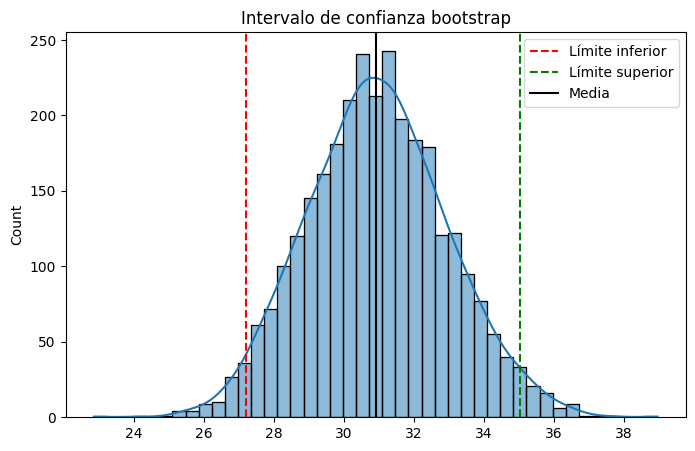

In [6]:
bootstrap_means = []

for _ in range(3000):
    bs = muestra.sample(n=len(muestra), replace=True)
    bootstrap_means.append(bs["age"].mean())

bootstrap_means = pd.Series(bootstrap_means)

li = bootstrap_means.quantile(0.025)
ls = bootstrap_means.quantile(0.975)

print("Media muestral:", round(muestra['age'].mean(), 2))
print("IC bootstrap 95%:", (round(li, 2), round(ls, 2)))

plt.figure(figsize=(8,5))
sns.histplot(bootstrap_means, kde=True)
plt.axvline(li, color="red", linestyle="--", label="Límite inferior")
plt.axvline(ls, color="green", linestyle="--", label="Límite superior")
plt.axvline(muestra["age"].mean(), color="black", label="Media")
plt.title("Intervalo de confianza bootstrap")
plt.legend()
plt.show()